# IDK embeddings: whole trajectories and trajectory windows

## Using 4d State [x, x', theta, theta']

**Part 1 — Whole trajectories:** HDBSCAN and spectral clustering, with cluster-colored
UMAP and t-SNE plots. Here, “whole” means a whole prepared segment, not necessarily
the original episode.

**Part 2 — Trajectory windows (25 steps):** UMAP and t-SNE of every window, colored
by the original trajectory's saved success/failure label.

Use the project's notebook environment (`python -m pip install -e ".[nb]"`) and run
all cells from the repository root or `notebooks/`. Only embedding artifacts are
needed; no fitting, raw trajectory loading, or re-embedding occurs.

---

# Part 1 — Whole trajectories

Compare **HDBSCAN** (density-based clusters and noise) with **spectral clustering**
(a fixed number of groups). Color **UMAP** and **t-SNE** by HDBSCAN assignments,
then show spectral assignments on the same coordinates. Clustering uses the original
IDK embedding geometry. Checkpoint and return metadata are used only afterward to
interpret the clusters.


In [26]:
import json
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.manifold import TSNE
from umap import UMAP

from cartpole_idk.analytics.clustering import cluster_units
from cartpole_idk.analytics.evaluation import cluster_summary, evaluate_clusters
from cartpole_idk.analytics.metrics import pairwise
from cartpole_idk.artifacts import EmbeddingArtifact
from cartpole_idk.model import ClusterConfig

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run from the repository root or notebooks directory.")

ARTIFACT_DIR = ROOT / (
    "artifacts/embeddings/200000-iter_nominal_500_episodes/"
    "psi-32_t-100_vanilla-state/10K-natfail-100ep_200K-nom-100ep/whole"
)
OUTPUT_DIR = ROOT / "artifacts/analysis/cluster-example/vanilla-state/cluster-example-whole"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MIN_CLUSTER_SIZE = 10
MIN_SAMPLES = 5
SPECTRAL_CLUSTERS = 2
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
TSNE_PERPLEXITY = 30.0

## Load the artifact and inspect its population

Rows remain in artifact order throughout. `source_return` describes the original
rollout; `segment_return` and `raw_length` describe the prepared data being embedded.
The preparation `success` flag is a source-length threshold label, not a cluster label.


In [27]:
artifact = EmbeddingArtifact.load(ARTIFACT_DIR)
embedded = artifact.embeddings
units = pd.DataFrame([unit.record() for unit in embedded.units])
assert artifact.config.unit.mode == "whole"
assert embedded.values.shape[0] == len(units)

print(f"{len(units)} units × {embedded.values.shape[1]} embedding features")
print(
    f"Representation: {artifact.config.fit.idk.representation}; psi={embedded.psi}; t={embedded.t}"
)
display(
    units.groupby("checkpoint_id").agg(
        units=("unit_id", "size"),
        mean_source_return=("source_return", "mean"),
        mean_segment_return=("segment_return", "mean"),
        min_segment_length=("raw_length", "min"),
        max_segment_length=("raw_length", "max"),
        successful_sources=("success", "sum"),
    )
)

200 units × 3200 embedding features
Representation: state; psi=32; t=100


,units,mean_source_return,mean_segment_return,min_segment_length,max_segment_length,successful_sources
checkpoint_id,,,,,,
step_000010000,100,97.61,94.19,83,100,0
step_000200000,100,500.00,100.00,100,100,100


## Cluster in the original embedding space

IDK distance is `||embedding_i - embedding_j|| / sqrt(t)`. HDBSCAN uses this distance
with `min_cluster_size=10` and `min_samples=5`; label **-1** means noise. Its membership
strength measures association with the assigned cluster, not probability of failure.

Spectral clustering uses native IDK affinity and requests **two clusters** as an
explicit comparison setting. It assigns every unit, so it has no noise category.
Neither method sees the checkpoint or success labels.


In [28]:
distances = pairwise(embedded, metric="idk-distance")
affinity = pairwise(embedded, metric="idk")
assert np.isfinite(distances).all() and np.allclose(distances, distances.T)
np.fill_diagonal(distances, 0.0)

hdbscan_config = ClusterConfig(
    algorithm="hdbscan",
    distance="idk-distance",
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
)
spectral_config = ClusterConfig(
    algorithm="spectral",
    n_clusters=SPECTRAL_CLUSTERS,
    random_state=SEED,
)
hdbscan_result = cluster_units(embedded, hdbscan_config, precomputed=distances)
spectral_result = cluster_units(embedded, spectral_config, precomputed=affinity)
results = {"HDBSCAN": hdbscan_result, "Spectral": spectral_result}

## Quantitative diagnostics

Silhouette is measured in the original IDK distances. HDBSCAN noise is excluded from
silhouette, adjusted mutual information (AMI), and purity; coverage and noise counts
are reported alongside them. Undefined silhouette is left missing. AMI and purity
compare clusters with metadata after fitting; they are not classification accuracy.


In [29]:
metrics = []
for name, result in results.items():
    report = evaluate_clusters(
        result.assignments, distances, categorical=("checkpoint_id", "success")
    )
    metrics.append(
        {
            "algorithm": name,
            "clusters": len(set(result.labels) - {-1}),
            "noise_units": report["n_noise"],
            "clustered_fraction": report["n_evaluated"] / len(units),
            "silhouette": report["silhouette"],
            "checkpoint_AMI": report["checkpoint_id"]["adjusted_mutual_information"],
            "checkpoint_purity": report["checkpoint_id"]["purity"],
            "success_AMI": report["success"]["adjusted_mutual_information"],
        }
    )
metrics = pd.DataFrame(metrics).set_index("algorithm")
display(metrics.round(3))

hdbscan_summary, hdbscan_composition = cluster_summary(
    hdbscan_result.assignments, categorical=("checkpoint_id", "success")
)
strengths = hdbscan_result.assignments.groupby("cluster")["membership_strength"].mean()
hdbscan_summary = hdbscan_summary.join(strengths.rename("mean_membership_strength"), on="cluster")
print("HDBSCAN clusters: return statistics describe the original source episodes.")
display(hdbscan_summary.round(3))
print("HDBSCAN cluster composition by checkpoint (including noise, if any):")
display(pd.crosstab(hdbscan_result.labels, units["checkpoint_id"], rownames=["cluster"]))
print("Assignment agreement; cluster numbers are independent between algorithms:")
display(
    pd.crosstab(
        hdbscan_result.labels, spectral_result.labels, rownames=["HDBSCAN"], colnames=["Spectral"]
    )
)

,clusters,noise_units,clustered_fraction,silhouette,checkpoint_AMI,checkpoint_purity,success_AMI
algorithm,,,,,,,
HDBSCAN,3,2,0.99,0.457,0.805,1.00,0.805
Spectral,2,0,1.00,0.302,0.643,0.91,0.643


HDBSCAN clusters: return statistics describe the original source episodes.


,cluster,count,return_count,mean_return,median_return,std_return,mean_membership_strength
0,-1,2,2,500.000,500.0,0.000,0.000
1,0,37,37,108.270,107.0,4.903,0.875
2,1,63,63,91.349,90.0,6.392,0.875
3,2,98,98,500.000,500.0,0.000,0.953


HDBSCAN cluster composition by checkpoint (including noise, if any):


checkpoint_id,step_000010000,step_000200000
cluster,,
-1,0,2
0,37,0
1,63,0
2,0,98


Assignment agreement; cluster numbers are independent between algorithms:


Spectral,0,1
HDBSCAN,,
-1,2,0
0,0,37
1,0,63
2,80,18


## UMAP and t-SNE, colored by HDBSCAN

Both projections receive the same precomputed IDK distances. They are visualization
methods, not additional clustering algorithms. The seed and settings below make each
run reproducible in the same software environment. t-SNE uses random initialization
because PCA initialization is unavailable for precomputed distances.

HDBSCAN colors and noise markers are identical across panels. Apparent 2D separation,
cluster area, and spacing are not quantitative evidence of cluster quality; use the
original-space diagnostics above.


In [30]:
if not 2 <= UMAP_NEIGHBORS < len(units):
    raise ValueError("UMAP_NEIGHBORS must be between 2 and n_units - 1.")
if not 0 < TSNE_PERPLEXITY < len(units):
    raise ValueError("TSNE_PERPLEXITY must be positive and less than n_units.")

umap_coordinates = UMAP(
    n_components=2,
    metric="precomputed",
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    random_state=SEED,
    n_jobs=1,
).fit_transform(distances.copy())
tsne_model = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    perplexity=TSNE_PERPLEXITY,
    learning_rate="auto",
    max_iter=1500,
    random_state=SEED,
)
tsne_coordinates = tsne_model.fit_transform(distances.copy())
projections = {"UMAP": umap_coordinates, "t-SNE": tsne_coordinates}
print(f"Final t-SNE KL divergence: {tsne_model.kl_divergence_:.4f}")

/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


Final t-SNE KL divergence: 0.0990


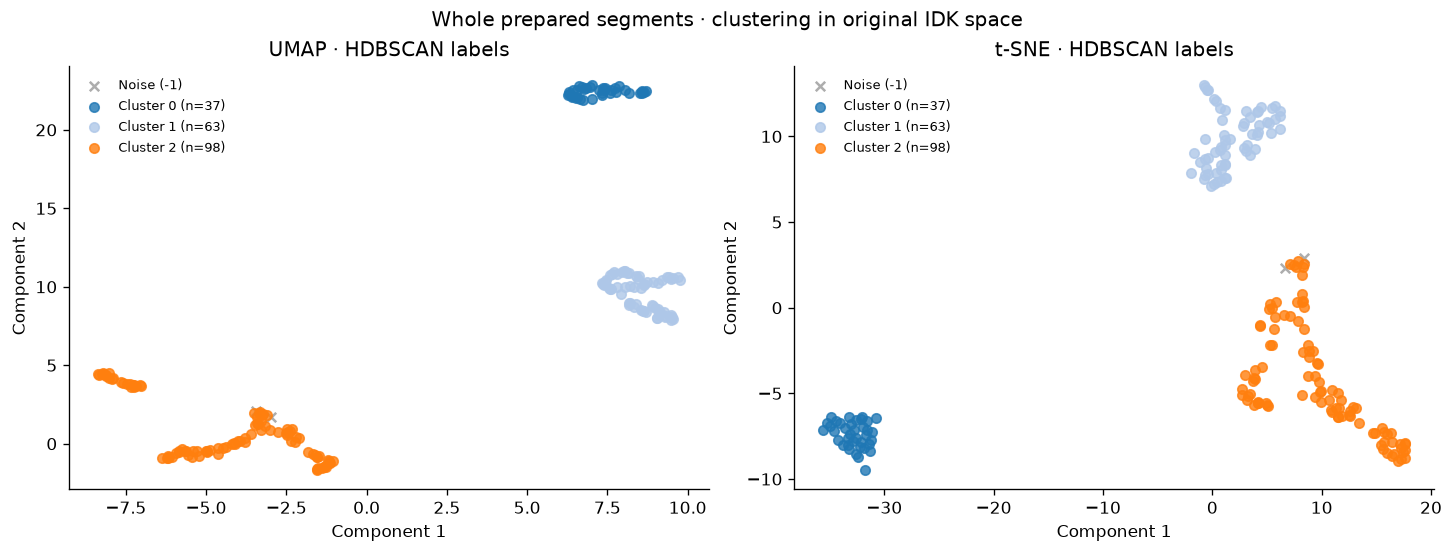

In [31]:
def plot_clusters(ax, coordinates, labels, title):
    """Use consistent categorical colors and a separate gray marker for noise."""
    for label in sorted(np.unique(labels)):
        selected = labels == label
        ax.scatter(
            coordinates[selected, 0],
            coordinates[selected, 1],
            c=["#999999" if label < 0 else plt.get_cmap("tab20")(int(label) % 20)],
            marker="x" if label < 0 else "o",
            s=32,
            alpha=0.8,
            label="Noise (-1)" if label < 0 else f"Cluster {label} (n={selected.sum()})",
        )
    ax.set(title=title, xlabel="Component 1", ylabel="Component 2")
    ax.legend(fontsize=8, frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, projections.items(), strict=True):
    plot_clusters(ax, coordinates, hdbscan_result.labels, f"{name} · HDBSCAN labels")
fig.suptitle("Whole prepared segments · clustering in original IDK space")
fig.savefig(OUTPUT_DIR / "hdbscan_umap_tsne.png", dpi=180)
plt.show()

## Spectral comparison and source returns

Reuse the same projection coordinates so only the labels change. Cluster IDs are
arbitrary and colors do not establish correspondence between the two algorithms.
The return plot helps interpret HDBSCAN groups using original episode outcomes.


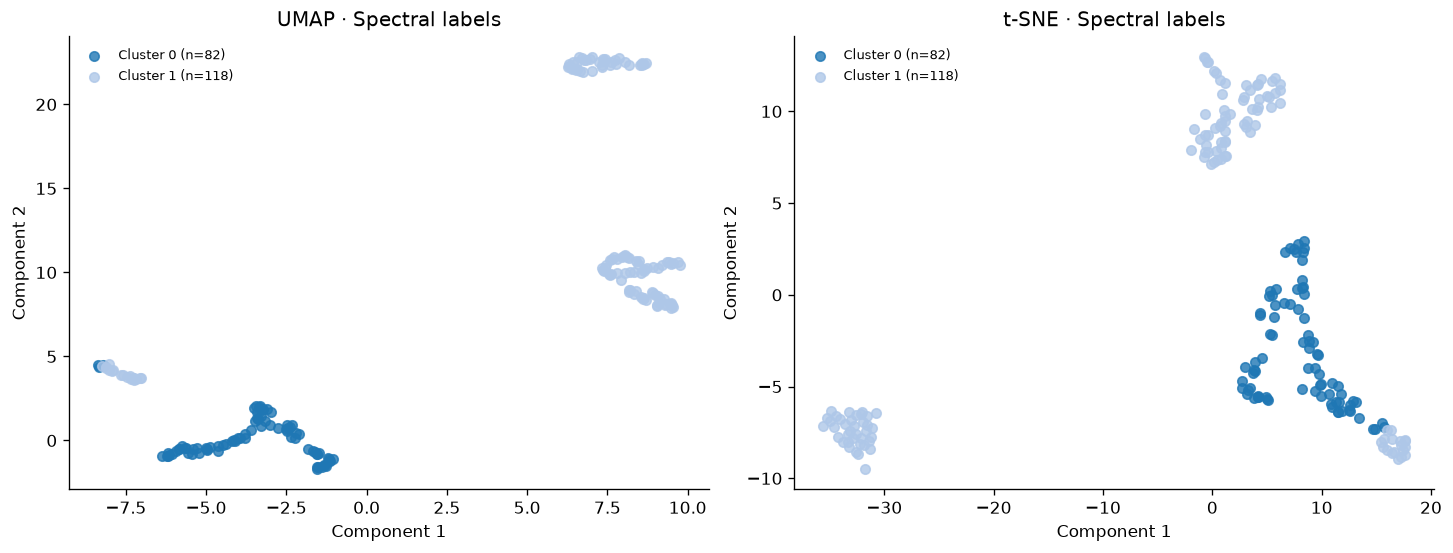

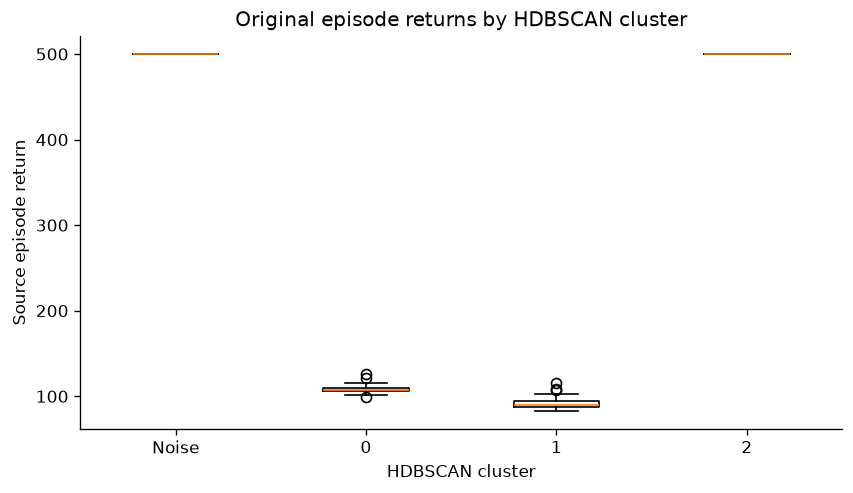

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, projections.items(), strict=True):
    plot_clusters(ax, coordinates, spectral_result.labels, f"{name} · Spectral labels")
fig.savefig(OUTPUT_DIR / "spectral_umap_tsne.png", dpi=180)
plt.show()

cluster_ids = sorted(np.unique(hdbscan_result.labels))
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.boxplot(
    [
        units.loc[hdbscan_result.labels == label, "source_return"].to_numpy()
        for label in cluster_ids
    ],
    tick_labels=["Noise" if label < 0 else str(label) for label in cluster_ids],
)
ax.set(
    xlabel="HDBSCAN cluster",
    ylabel="Source episode return",
    title="Original episode returns by HDBSCAN cluster",
)
fig.savefig(OUTPUT_DIR / "hdbscan_source_returns.png", dpi=180)
plt.show()

## Save assignments, coordinates, and settings

The output directory contains per-unit assignments, membership strengths, both 2D
coordinates, quantitative summaries, and PNG figures. Re-running replaces these
notebook outputs, leaving the input artifact unchanged. Checkpoint and success are
related in this population, so their agreement with clusters is descriptive evidence,
not a held-out failure-detection evaluation.


In [33]:
assignments = units.copy()
assignments["hdbscan_cluster"] = hdbscan_result.labels
assignments["hdbscan_membership_strength"] = hdbscan_result.probabilities
assignments["spectral_cluster"] = spectral_result.labels
assignments[["umap_1", "umap_2"]] = umap_coordinates
assignments[["tsne_1", "tsne_2"]] = tsne_coordinates
assignments.to_parquet(OUTPUT_DIR / "assignments.parquet", index=False)
metrics.to_csv(OUTPUT_DIR / "metrics.csv")
hdbscan_summary.to_csv(OUTPUT_DIR / "hdbscan_summary.csv", index=False)
hdbscan_composition.to_csv(OUTPUT_DIR / "hdbscan_composition.csv", index=False)

settings = {
    "artifact": str(ARTIFACT_DIR.relative_to(ROOT)),
    "artifact_id": artifact.metadata.artifact_id,
    "fit_id": embedded.basis_id,
    "seed": SEED,
    "hdbscan": hdbscan_config.model_dump(mode="json"),
    "spectral": spectral_config.model_dump(mode="json"),
    "umap": {
        "metric": "precomputed",
        "n_neighbors": UMAP_NEIGHBORS,
        "min_dist": UMAP_MIN_DIST,
        "n_components": 2,
    },
    "tsne": {
        "metric": "precomputed",
        "perplexity": TSNE_PERPLEXITY,
        "init": "random",
        "learning_rate": "auto",
        "max_iter": 1500,
        "n_components": 2,
        "kl_divergence": float(tsne_model.kl_divergence_),
    },
    "versions": {
        name: version(name)
        for name in ["cartpole-idk", "numpy", "scikit-learn", "umap-learn", "matplotlib"]
    },
}
(OUTPUT_DIR / "settings.json").write_text(json.dumps(settings, indent=2) + "\n")
print(f"Saved results to {OUTPUT_DIR.relative_to(ROOT)}")

Saved results to artifacts/analysis/cluster-example/vanilla-state/cluster-example-whole


---

# Part 2 — Trajectory windows (25 steps)

Each point is one **25-transition window**. Color indicates the **source trajectory's
saved success/failure label**, not an HDBSCAN assignment or the outcome of that
particular window. Successful/failing labels come from preparation's source-length
threshold and are used only for coloring, never as input to UMAP or t-SNE.

All windows are included. Consecutive windows overlap, and longer prepared segments
contribute more points; point density therefore does not represent independent
trajectory counts. The table below reports both windows and source trajectories.

In [34]:
from sklearn.decomposition import TruncatedSVD

WINDOW_ARTIFACT_DIR = ARTIFACT_DIR.parent / "window-25"
WINDOW_OUTPUT_DIR = ROOT / "artifacts/analysis/cluster-example/vanilla-state/cluster-example-window-25"
WINDOW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_SVD_COMPONENTS = 50
WINDOW_UMAP_NEIGHBORS = 15
WINDOW_UMAP_MIN_DIST = 0.1
WINDOW_TSNE_PERPLEXITY = 30.0

window_artifact = EmbeddingArtifact.load(WINDOW_ARTIFACT_DIR)
artifact.compatible_with(window_artifact)
window_embedded = window_artifact.embeddings
window_units = pd.DataFrame([unit.record() for unit in window_embedded.units])
assert window_artifact.config.unit.mode == "window"
assert window_artifact.config.unit.window_length == 25
assert window_units["raw_length"].eq(25).all()

# Read the source label directly; a short window is not itself a failure.
if not window_units["success"].map(lambda value: isinstance(value, (bool, np.bool_))).all():
    raise ValueError("Each window must have a saved boolean source-trajectory success label.")
source_labels = window_units.groupby(["source_dataset", "source_trajectory_id"])["success"]
if source_labels.nunique().ne(1).any():
    raise ValueError("Windows from the same source trajectory have inconsistent labels.")
window_units["trajectory_truth"] = window_units["success"].map(
    {True: "Successful trajectory", False: "Failing trajectory"}
)
window_counts = window_units.groupby("trajectory_truth").agg(windows=("unit_id", "size"))
trajectory_counts = (
    window_units.drop_duplicates(["source_dataset", "source_trajectory_id"])
    .groupby("trajectory_truth")
    .size()
    .rename("source_trajectories")
)
window_population = window_counts.join(trajectory_counts)
print(f"{len(window_units):,} windows × {window_embedded.values.shape[1]:,} embedding features")
print(f"Window stride: {window_artifact.config.unit.stride} transition(s)")
display(window_population)

14,619 windows × 3,200 embedding features
Window stride: 1 transition(s)


,windows,source_trajectories
trajectory_truth,,
Failing trajectory,7019,100
Successful trajectory,7600,100


## Project all windows

A dense pairwise distance matrix for these windows would contain over 213 million
entries. Instead, Euclidean distance on `embedding / sqrt(t)` gives the same IDK
distance while keeping UMAP's input sparse.

For t-SNE, first reduce that sparse input to **50 SVD components**. This is an
approximation to the original geometry; the retained variance is printed below.
UMAP and t-SNE coordinates have independent axes and are for visual exploration.
The source truth labels are not passed to either method.

In [35]:
window_features = window_embedded.values / np.sqrt(window_embedded.t)
window_svd = TruncatedSVD(n_components=WINDOW_SVD_COMPONENTS, random_state=SEED)
window_reduced = window_svd.fit_transform(window_features)
window_retained_variance = float(window_svd.explained_variance_ratio_.sum())
print(
    f"t-SNE input: {WINDOW_SVD_COMPONENTS} SVD components retain "
    f"{window_retained_variance:.1%} of embedding variance"
)

window_umap_model = UMAP(
    n_components=2,
    metric="euclidean",
    n_neighbors=WINDOW_UMAP_NEIGHBORS,
    min_dist=WINDOW_UMAP_MIN_DIST,
    random_state=SEED,
    n_jobs=1,
)
window_umap_coordinates = window_umap_model.fit_transform(window_features)
print("Window UMAP complete")

window_tsne_model = TSNE(
    n_components=2,
    metric="euclidean",
    init="pca",
    perplexity=WINDOW_TSNE_PERPLEXITY,
    learning_rate="auto",
    max_iter=1500,
    random_state=SEED,
)
window_tsne_coordinates = window_tsne_model.fit_transform(window_reduced)
print(f"Window t-SNE complete; final KL divergence: {window_tsne_model.kl_divergence_:.4f}")
assert np.isfinite(window_umap_coordinates).all()
assert np.isfinite(window_tsne_coordinates).all()

t-SNE input: 50 SVD components retain 97.9% of embedding variance


/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Window UMAP complete
Window t-SNE complete; final KL divergence: 0.3913


## Color windows by trajectory truth

Blue points come from successful trajectories; orange points come from failing
trajectories. Both plots use the same labels and colors. Draw points in a seeded,
shuffled order so one trajectory class is not systematically painted over the other.

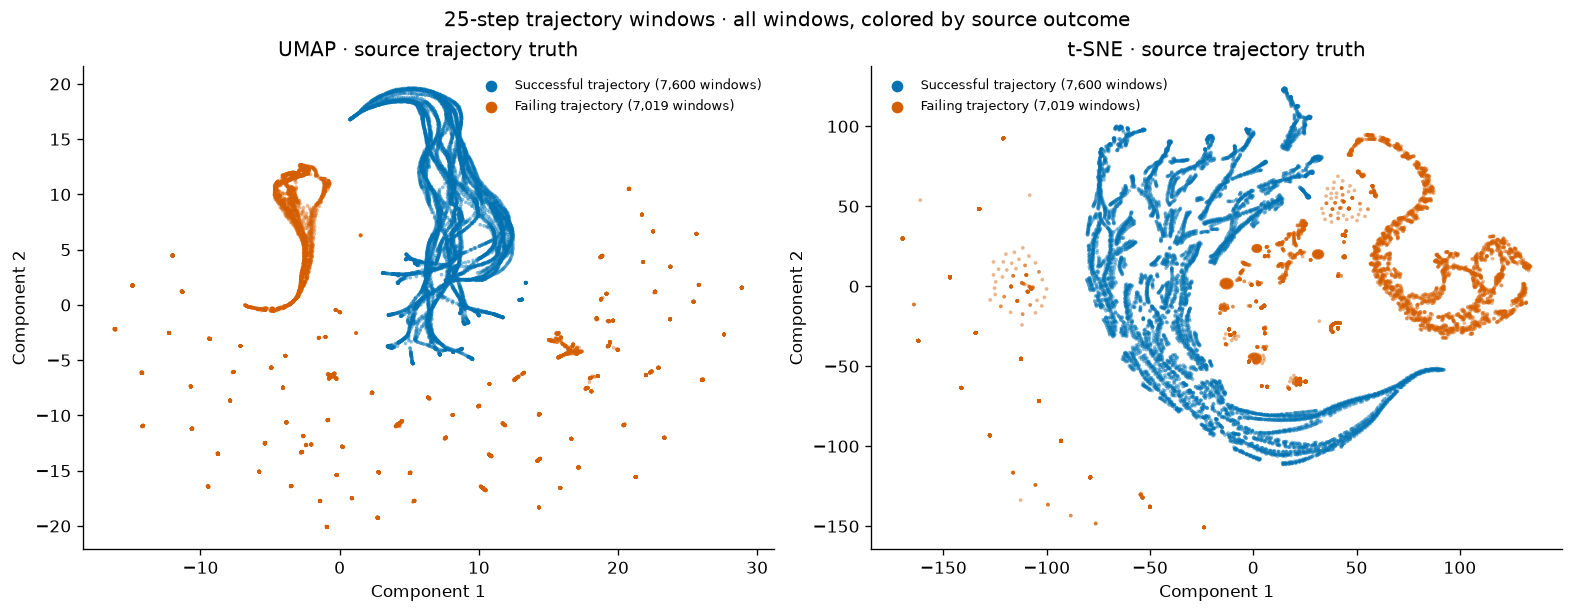

In [36]:
truth_colors = {"Successful trajectory": "#0072B2", "Failing trajectory": "#D55E00"}
window_point_colors = window_units["trajectory_truth"].map(truth_colors).to_numpy()
window_plot_order = np.random.default_rng(SEED).permutation(len(window_units))
window_projections = {"UMAP": window_umap_coordinates, "t-SNE": window_tsne_coordinates}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, window_projections.items(), strict=True):
    ax.scatter(
        coordinates[window_plot_order, 0],
        coordinates[window_plot_order, 1],
        c=window_point_colors[window_plot_order],
        s=5,
        alpha=0.45,
        linewidths=0,
        rasterized=True,
    )
    for truth, color in truth_colors.items():
        count = window_units["trajectory_truth"].eq(truth).sum()
        ax.scatter([], [], c=color, s=25, label=f"{truth} ({count:,} windows)")
    ax.set(title=f"{name} · source trajectory truth", xlabel="Component 1", ylabel="Component 2")
    ax.legend(fontsize=8, frameon=False, markerscale=1.2)
fig.suptitle("25-step trajectory windows · all windows, colored by source outcome")
fig.savefig(WINDOW_OUTPUT_DIR / "trajectory_truth_umap_tsne.png", dpi=180)
plt.show()

## Save window coordinates and labels

Save each point's unit ID, source trajectory, window offsets, truth label, and both
projection coordinates. Re-running replaces these window outputs; whole-trajectory
results remain in their own output directory.

In [37]:
window_points = window_units.copy()
window_points[["umap_1", "umap_2"]] = window_umap_coordinates
window_points[["tsne_1", "tsne_2"]] = window_tsne_coordinates
window_points.to_parquet(WINDOW_OUTPUT_DIR / "points.parquet", index=False)
window_population.to_csv(WINDOW_OUTPUT_DIR / "population.csv")
window_settings = {
    "artifact": str(WINDOW_ARTIFACT_DIR.relative_to(ROOT)),
    "artifact_id": window_artifact.metadata.artifact_id,
    "fit_id": window_embedded.basis_id,
    "unit": window_artifact.config.unit.model_dump(mode="json"),
    "n_windows": len(window_units),
    "seed": SEED,
    "truth_field": "success",
    "truth_colors": truth_colors,
    "feature_scaling": "embedding / sqrt(t)",
    "umap": {
        "n_components": 2,
        "metric": "euclidean",
        "n_neighbors": WINDOW_UMAP_NEIGHBORS,
        "min_dist": WINDOW_UMAP_MIN_DIST,
        "n_jobs": 1,
    },
    "tsne": {
        "n_components": 2,
        "metric": "euclidean",
        "init": "pca",
        "perplexity": WINDOW_TSNE_PERPLEXITY,
        "learning_rate": "auto",
        "max_iter": 1500,
        "svd_components": WINDOW_SVD_COMPONENTS,
        "svd_retained_variance": window_retained_variance,
        "kl_divergence": float(window_tsne_model.kl_divergence_),
    },
    "versions": settings["versions"],
}
(WINDOW_OUTPUT_DIR / "settings.json").write_text(json.dumps(window_settings, indent=2) + "\n")
print(f"Saved window results to {WINDOW_OUTPUT_DIR.relative_to(ROOT)}")

Saved window results to artifacts/analysis/cluster-example/vanilla-state/cluster-example-window-25
